# MechMedic - 3500-DEFault diesel-engine dataset Using Random Forest

In [ ]:
#Extract Zip files
import zipfile
import os

zip_path = "/content/Diesel Engine Faults Features Dataset (3500-DEFault).zip"
extract_path = "/content/3500_DEFault"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

/content/3500_DEFault/Diesel Engine Faults Features Dataset (3500-DEFault)/Features_2500RPM_15dB_full.mat
/content/3500_DEFault/Diesel Engine Faults Features Dataset (3500-DEFault)/Features_2500RPM_60dB_full.mat
/content/3500_DEFault/Diesel Engine Faults Features Dataset (3500-DEFault)/Features_2500RPM_30dB_full.mat
/content/3500_DEFault/Diesel Engine Faults Features Dataset (3500-DEFault)/Features_2500RPM_0dB_full.mat


In [ ]:
#Inspect the 60 dB file
# Import loadmat to read MATLAB (.mat) files
from scipy.io import loadmat

# Import os to work with file and folder paths
import os

# Import NumPy for working with numerical data
import numpy as np


# Create the path to the 60 dB dataset file
file_path = os.path.join(
    extract_path,
    "Diesel Engine Faults Features Dataset (3500-DEFault)",
    "Features_2500RPM_60dB_full.mat"
)


# Load the MATLAB (.mat) file
data = loadmat(file_path)


# Display a heading for the output
print("Variables inside the file:\n")


# Go through each variable stored inside the .mat file
for key, value in data.items():

    # Ignore MATLAB's internal variables such as __header__, __version__, etc.
    if not key.startswith("__"):

        # Display the name of the variable
        print("Variable:", key)

        # Display the dimensions of the variable
        print("Shape:", getattr(value, "shape", None))

        # Display the data type of the variable
        print("Data type:", getattr(value, "dtype", None))

        # Print an empty line for better readability
        print()

Variables inside the file:

Variable: None
Shape: (1,)
Data type: [('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]



In [ ]:
#Inspect the structure
# Get the main dataset stored under the variable name "None"
dataset = data["None"]


# Display the overall shape of the dataset
print("Main shape:", dataset.shape)

# Display the names of the fields present in the structured dataset
print("Fields:", dataset.dtype.names)


# Get the first record from the dataset
# We use [0] because the dataset is one-dimensional with shape (1,)
record = dataset[0]


# Go through each field present in the record
for field in dataset.dtype.names:

    # Get the value stored in the current field
    value = record[field]

    # Display the name of the field
    print("\nField:", field)

    # Display the Python type of the field
    print("Type:", type(value))

    # Display the shape of the field, if it has one
    print("Shape:", getattr(value, "shape", None))

    # Display the data type of the field, if available
    print("Data type:", getattr(value, "dtype", None))

Main shape: (1,)
Fields: ('s0', 's1', 's2', 'arr')

Field: s0
Type: <class 'bytes'>
Shape: None
Data type: None

Field: s1
Type: <class 'bytes'>
Shape: None
Data type: None

Field: s2
Type: <class 'bytes'>
Shape: None
Data type: None

Field: arr
Type: <class 'numpy.ndarray'>
Shape: (6, 1)
Data type: uint32


In [ ]:
#Check the MATLAB file format
import h5py

print("Is HDF5/MATLAB v7.3 file:", h5py.is_hdf5(file_path))

Is HDF5/MATLAB v7.3 file: False


In [ ]:
# Get the first record stored inside the variable "None"
# The dataset has shape (1,), so we use [0] instead of [0, 0]
record = data["None"][0]


# ---------------------------------------------------------
# Display the raw contents of each field
# ---------------------------------------------------------

# Print the content stored in field s0
print("s0:")
print(record["s0"])
print()

# Print the content stored in field s1
print("s1:")
print(record["s1"])
print()

# Print the content stored in field s2
print("s2:")
print(record["s2"])
print()

# Print the small numeric array stored in the 'arr' field
print("arr:")
print(record["arr"])


# ---------------------------------------------------------
# Try to convert the byte fields into readable text
# ---------------------------------------------------------

print("\nDecoded values:")

# Check each byte field one by one
for field in ["s0", "s1", "s2"]:

    # Get the value stored in the current field
    value = record[field]

    # Check whether the value is stored as bytes
    if isinstance(value, bytes):

        try:
            # Convert bytes into readable UTF-8 text
            print(field, ":", value.decode("utf-8"))

        except:
            # If decoding is not possible, display the original value
            print(field, ":", value)

s0:
b'DataBase_table'

s1:
b'MCOS'

s2:
b'table'

arr:
[[3707764736]
 [         2]
 [         1]
 [         1]
 [         1]
 [         1]]

Decoded values:
s0 : DataBase_table
s1 : MCOS
s2 : table


In [ ]:
# Import loadmat for reading the MATLAB file
from scipy.io import loadmat


# Reload the .mat file using simplify_cells=True
# This tries to simplify MATLAB structures, cells and objects
# into easier Python data structures
data_simple = loadmat(
    file_path,
    simplify_cells=True
)


# Display all variables found in the file
print("Variables after simplifying:\n")

for key, value in data_simple.items():

    # Ignore MATLAB internal information
    if not key.startswith("__"):

        # Display the variable name
        print("Variable:", key)

        # Display its Python type
        print("Type:", type(value))

        # Display its shape if available
        print("Shape:", getattr(value, "shape", None))

        # Display its data type if available
        print("Data type:", getattr(value, "dtype", None))

        print()

Variables after simplifying:

Variable: None
Type: <class 'scipy.io.matlab._mio5_params.MatlabOpaque'>
Shape: (1,)
Data type: [('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')]



In [ ]:
# Open the MATLAB file in binary mode
# We only read the beginning of the file to inspect its header
with open(file_path, "rb") as file:

    # Read the first 128 bytes of the MAT file
    header = file.read(128)


# Display the file header
# errors="replace" prevents decoding errors from stopping the code
print("MAT-file header:\n")
print(header.decode("latin-1", errors="replace"))

MAT-file header:

MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Wed Apr  1 14:17:15 2020                                        Û        IM


In [ ]:
# Import scipy.io for working with MATLAB MAT files
import scipy.io

# Load the MAT file while keeping MATLAB structures
# in their original form as much as possible
mat_data = scipy.io.loadmat(
    file_path,
    struct_as_record=False,
    squeeze_me=False
)


# Display every top-level key found after loading
print("Keys found in the MAT file:")

for key in mat_data.keys():
    print(key)


# Display information about each non-internal variable
print("\nVariable details:")

for key, value in mat_data.items():

    # Skip MATLAB metadata variables
    if not key.startswith("__"):

        print("\nVariable name:", key)
        print("Python type:", type(value))
        print("Shape:", getattr(value, "shape", None))

        # Show the representation without trying
        # to convert it into a feature matrix yet
        print("Representation:")
        print(repr(value)[:1000])

Keys found in the MAT file:
__header__
__version__
__globals__
None
__function_workspace__

Variable details:

Variable name: None
Python type: <class 'scipy.io.matlab._mio5_params.MatlabOpaque'>
Shape: (1,)
Representation:
MatlabOpaque([(b'DataBase_table', b'MCOS', b'table', array([[3707764736],
                     [         2],
                     [         1],
                     [         1],
                     [         1],
                     [         1]], dtype=uint32))                       ],
             dtype=[('s0', 'O'), ('s1', 'O'), ('s2', 'O'), ('arr', 'O')])


In [ ]:
# Get the hidden MATLAB function workspace
# This workspace may contain information used to reconstruct
# the DataBase_table MATLAB object
workspace = mat_data["__function_workspace__"]


# Display basic information about the workspace
print("Function workspace information:")

# Display the Python object type
print("Python type:", type(workspace))

# Display the dimensions of the workspace
print("Shape:", getattr(workspace, "shape", None))

# Display the data type
print("Data type:", getattr(workspace, "dtype", None))

# Display the total number of elements
print("Number of elements:", getattr(workspace, "size", None))


# Display only the beginning of the workspace
# We limit it to 2000 characters because the workspace
# may contain a large amount of information
print("\nBeginning of workspace representation:")
print(repr(workspace)[:2000])

Function workspace information:
Python type: <class 'numpy.ndarray'>
Shape: (1, 2729600)
Data type: uint8
Number of elements: 2729600

Beginning of workspace representation:
array([[ 0,  1, 73, ...,  0,  0,  0]], dtype=uint8)


In [ ]:
# Install GNU Octave in Google Colab
# Octave is compatible with many MATLAB files and may be able
# to load the DataBase_table object that SciPy cannot reconstruct

!apt-get update -qq
!apt-get install -y octave > /dev/null 2>&1

# Check whether Octave was installed successfully
!octave --version | head -n 3

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
octave: X11 DISPLAY environment variable not set
octave: disabling GUI features
GNU Octave, version 8.4.0
Copyright (C) 1993-2023 The Octave Project Developers.
This is free software; see the source code for copying conditions.


In [ ]:
# Import os for checking files and folders
import os


# Define the exact path of the 60 dB dataset
mat_file = os.path.join(
    "/content/3500_DEFault",
    "Diesel Engine Faults Features Dataset (3500-DEFault)",
    "Features_2500RPM_60dB_full.mat"
)


# Display the complete file path
print("File path:")
print(mat_file)


# Check whether the file actually exists
print("\nFile exists:", os.path.exists(mat_file))

File path:
/content/3500_DEFault/Diesel Engine Faults Features Dataset (3500-DEFault)/Features_2500RPM_60dB_full.mat

File exists: True


In [ ]:
# Import subprocess so Python can run an Octave command
import subprocess


# Create the Octave command
# The command loads the verified MAT file and displays
# information about the variables stored inside it
octave_command = f"""
load('{mat_file}');
whos
"""


# Run Octave from Python
result = subprocess.run(
    ["octave", "--quiet", "--eval", octave_command],
    capture_output=True,
    text=True
)


# Display the output produced by Octave
print("Octave output:")
print(result.stdout)


# Display any error or warning messages separately
if result.stderr:
    print("\nOctave messages:")
    print(result.stderr)

Octave output:
Variables visible from the current scope:

variables in scope: top scope

  Attr   Name                Size                     Bytes  Class
  ====   ====                ====                     =====  ===== 
         DataBase_table      1x1                         24  struct

Total is 1 element using 24 bytes




In [ ]:
# Create an Octave command to inspect the structure
# of DataBase_table
octave_command = f"""
load('{mat_file}');

disp('Fields inside DataBase_table:');
fieldnames(DataBase_table)
"""


# Run the Octave command
result = subprocess.run(
    ["octave", "--quiet", "--eval", octave_command],
    capture_output=True,
    text=True
)


# Display the output from Octave
print("Octave output:")
print(result.stdout)


# Display any warnings or errors separately
if result.stderr:
    print("\nOctave messages:")
    print(result.stderr)

Octave output:
Fields inside DataBase_table:
ans =
{
  [1,1] = MCOS
  [2,1] = table
}




In [ ]:
# Create an Octave command to inspect the two fields
# inside DataBase_table without printing all the data
octave_command = f"""
load('{mat_file}');

disp('Information about MCOS field:');
whos DataBase_table.MCOS

disp('Size of MCOS field:');
disp(size(DataBase_table.MCOS));

disp('Class of MCOS field:');
disp(class(DataBase_table.MCOS));


disp('Information about table field:');
whos DataBase_table.table

disp('Size of table field:');
disp(size(DataBase_table.table));

disp('Class of table field:');
disp(class(DataBase_table.table));
"""


# Run the Octave command
result = subprocess.run(
    ["octave", "--quiet", "--eval", octave_command],
    capture_output=True,
    text=True
)


# Display the normal Octave output
print("Octave output:")
print(result.stdout)


# Display errors or warnings separately, if any
if result.stderr:
    print("\nOctave messages:")
    print(result.stderr)

Octave output:
Information about MCOS field:
Size of MCOS field:
   6   1
Class of MCOS field:
uint32
Information about table field:
Size of table field:


Octave messages:
error: structure has no member 'table'



In [ ]:
# Create an Octave command to display the complete
# DataBase_table structure that Octave reconstructed
octave_command = f"""
load('{mat_file}');

disp('Complete DataBase_table structure:');
disp(DataBase_table);
"""


# Run the Octave command
result = subprocess.run(
    ["octave", "--quiet", "--eval", octave_command],
    capture_output=True,
    text=True
)


# Display the normal output
print("Octave output:")
print(result.stdout)


# Display any warning or error messages separately
if result.stderr:
    print("\nOctave messages:")
    print(result.stderr)

Octave output:
Complete DataBase_table structure:
    MCOS =

      3707764736
               2
               1
               1
               1
               1

    table =



Octave messages:
error: octave_base_value::print (): wrong type argument '<unknown type>'



In [ ]:
y_pred = rf_model.predict(X_test)

In [ ]:
print(y_pred[:20])

[1 2 0 0 3 1 0 0 2 3 0 1 0 2 1 1 0 1 0 2]


In [ ]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(20)

,Actual,Predicted
0,3,1
1,1,2
2,3,0
3,3,0
4,3,3
5,2,1
6,1,0
7,2,0
8,3,2
9,3,3


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Random Forest Accuracy: 0.275
Accuracy Percentage: 27.500000000000004 %


In [ ]:
target_names = [
    "Normal",
    "Minor Fault",
    "Moderate Fault",
    "Severe Fault"
]

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names
))

                precision    recall  f1-score   support

        Normal       0.31      0.33      0.32        52
   Minor Fault       0.24      0.27      0.25        49
Moderate Fault       0.25      0.28      0.27        53
  Severe Fault       0.31      0.22      0.26        46

      accuracy                           0.28       200
     macro avg       0.28      0.27      0.27       200
  weighted avg       0.28      0.28      0.27       200



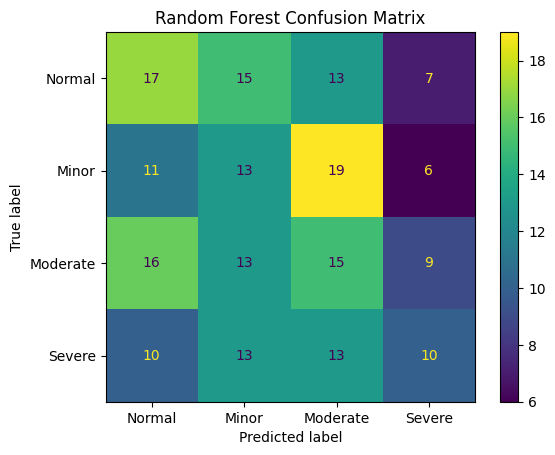

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Normal",
        "Minor",
        "Moderate",
        "Severe"
    ]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

In [ ]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

             Feature  Importance
2    Fuel_Efficiency    0.129572
0   Temperature (°C)    0.127641
1                RPM    0.127213
3        Vibration_X    0.125885
5        Vibration_Z    0.125512
7  Power_Output (kW)    0.122589
4        Vibration_Y    0.121964
6             Torque    0.119625


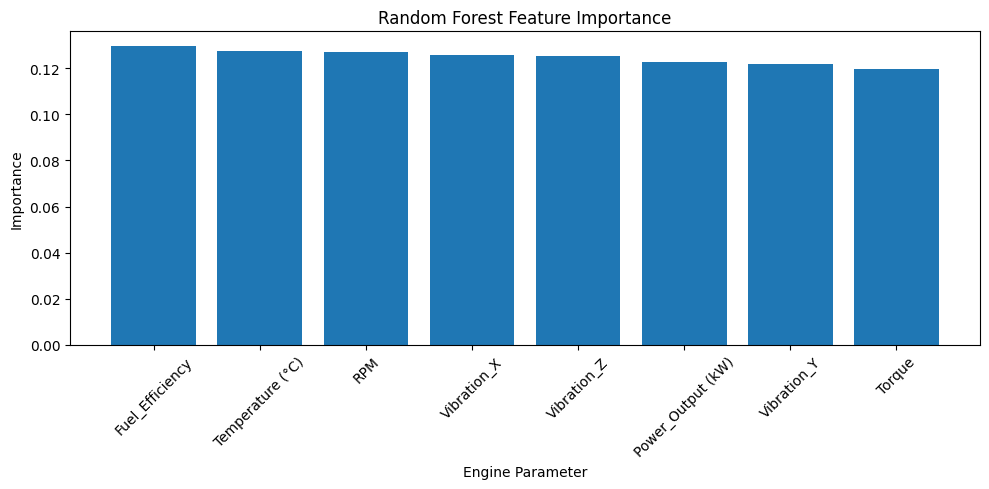

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Engine Parameter")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
sample = X_test.iloc[[0]]

print("Sensor values:")
print(sample)

Sensor values:
     Temperature (°C)          RPM  Fuel_Efficiency  Vibration_X  Vibration_Y  \
807         85.421236  1510.648943        16.555261      0.15645     0.625591   

     Vibration_Z     Torque  Power_Output (kW)  
807     0.187435  102.35803          98.369712  


In [ ]:
prediction = rf_model.predict(sample)[0]

print("Predicted class:", prediction)

Predicted class: 1


In [ ]:
fault_labels = {
    0: "Normal",
    1: "Minor Fault",
    2: "Moderate Fault",
    3: "Severe Fault"
}

print("Predicted Condition:", fault_labels[prediction])

Predicted Condition: Minor Fault


In [ ]:
actual = y_test.iloc[0]

print("Actual Condition:", fault_labels[actual])
print("Predicted Condition:", fault_labels[prediction])

Actual Condition: Severe Fault
Predicted Condition: Minor Fault
